In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the key tables
races = pd.read_csv('../data/races.csv')
results = pd.read_csv('../data/results.csv')
drivers = pd.read_csv('../data/drivers.csv')
constructors = pd.read_csv('../data/constructors.csv')
qualifying = pd.read_csv('../data/qualifying.csv')
driver_standings = pd.read_csv('../data/driver_standings.csv')
constructor_standings = pd.read_csv('../data/constructor_standings.csv')
circuits = pd.read_csv('../data/circuits.csv')
status = pd.read_csv('../data/status.csv')

print("✅ All files loaded!")
print(f"Races: {races.shape}")
print(f"Results: {results.shape}")
print(f"Drivers: {drivers.shape}")
print(f"Qualifying: {qualifying.shape}")
print(f"Driver standings: {driver_standings.shape}")

✅ All files loaded!
Races: (1125, 18)
Results: (26759, 18)
Drivers: (861, 9)
Qualifying: (10494, 9)
Driver standings: (34863, 7)


In [3]:
# Filter to modern era (2010 onwards) and explore the results table
races_modern = races[races['year'] >= 2010].copy()
print(f"Modern era races (2010+): {len(races_modern)}")
print(f"Years covered: {races_modern['year'].min()} - {races_modern['year'].max()}")
print(f"\nRaces per year:")
print(races_modern.groupby('year')['raceId'].count().to_string())

Modern era races (2010+): 305
Years covered: 2010 - 2024

Races per year:
year
2010    19
2011    19
2012    20
2013    19
2014    19
2015    19
2016    21
2017    20
2018    21
2019    21
2020    17
2021    22
2022    22
2023    22
2024    24


In [4]:
# Look at the results table - this is the most important table
print("Results table columns:")
print(results.columns.tolist())
print("\nFirst 3 rows:")
print(results.head(3).to_string())
print("\nUnique finish positions:")
print(sorted(results['positionOrder'].unique()))

Results table columns:
['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId']

First 3 rows:
   resultId  raceId  driverId  constructorId number  grid position positionText  positionOrder  points  laps         time milliseconds fastestLap rank fastestLapTime fastestLapSpeed  statusId
0         1      18         1              1     22     1        1            1              1    10.0    58  1:34:50.616      5690616         39    2       1:27.452         218.300         1
1         2      18         2              2      3     5        2            2              2     8.0    58       +5.478      5696094         41    3       1:27.739         217.586         1
2         3      18         3              3      7     7        3            3              3     6.0    58       +8.163      5698779         41    5       1

In [7]:
# Merge everything into one master dataframe
# Start with results + races to get the year
df = results.merge(races[['raceId', 'year', 'round', 'circuitId', 'name']], on='raceId')

# Add driver names
df = df.merge(drivers[['driverId', 'driverRef', 'forename', 'surname', 'nationality']], on='driverId')

# Add constructor names
df = df.merge(constructors[['constructorId', 'constructorRef', 'name']], on='constructorId', suffixes=('_race', '_constructor'))

# Add circuit info
df = df.merge(circuits[['circuitId', 'circuitRef', 'country']], on='circuitId')

# Add finish status (DNF, Finished, etc.)
df = df.merge(status[['statusId', 'status']], on='statusId')

# Filter to modern era
df = df[df['year'] >= 2024].copy()

# Create our target variable - podium finish (top 3)
df['podium'] = (df['positionOrder'] <= 3).astype(int)

# Create full driver name for readability
df['driver_name'] = df['forename'] + ' ' + df['surname']

print(f"Master dataframe shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nPodium finishes in dataset: {df['podium'].sum()}")
print(f"Non-podium: {(df['podium'] == 0).sum()}")
print(f"\nSample row:")
print(df[['year', 'round', 'driver_name', 'name_constructor', 'grid', 'positionOrder', 'podium', 'status']].head(5).to_string())

Master dataframe shape: (479, 33)

Columns: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId', 'year', 'round', 'circuitId', 'name_race', 'driverRef', 'forename', 'surname', 'nationality', 'constructorRef', 'name_constructor', 'circuitRef', 'country', 'status', 'podium', 'driver_name']

Podium finishes in dataset: 72
Non-podium: 407

Sample row:
       year  round      driver_name name_constructor  grid  positionOrder  podium    status
26280  2024      1   Max Verstappen         Red Bull     1              1       1  Finished
26281  2024      1     Sergio Pérez         Red Bull     5              2       1  Finished
26282  2024      1     Carlos Sainz          Ferrari     4              3       1  Finished
26283  2024      1  Charles Leclerc          Ferrari     2              4       0  Finished
26284  2024    

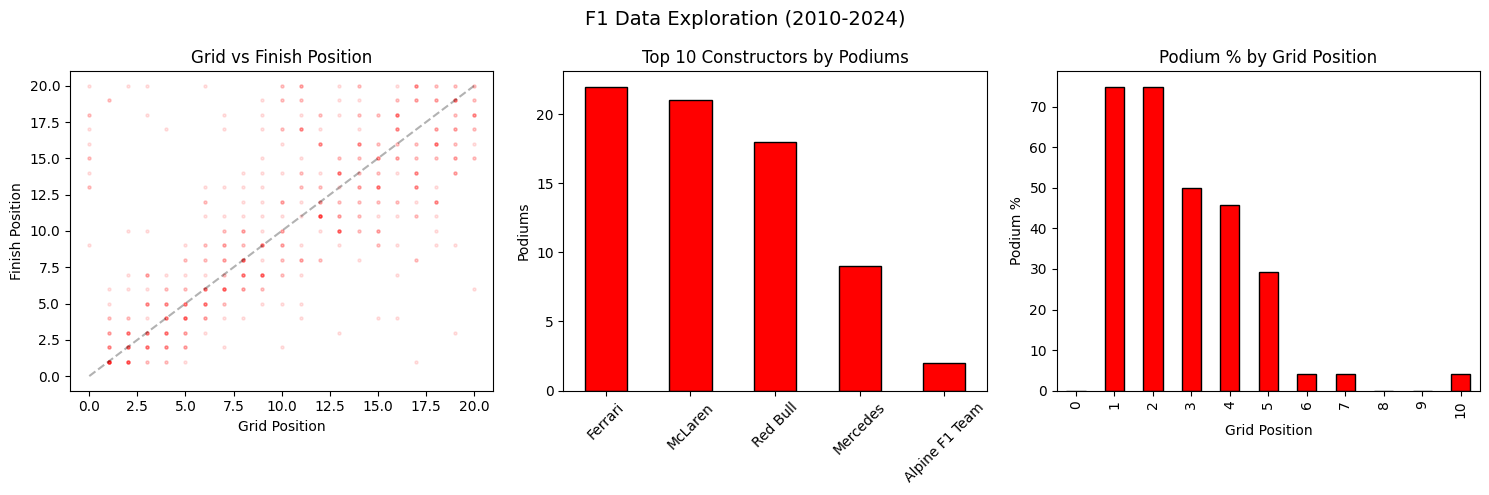

Charts saved!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('F1 Data Exploration (2010-2024)', fontsize=14)

# Plot 1: Grid position vs finish position
axes[0].scatter(df['grid'], df['positionOrder'], alpha=0.1, color='red', s=5)
axes[0].set_xlabel('Grid Position')
axes[0].set_ylabel('Finish Position')
axes[0].set_title('Grid vs Finish Position')
axes[0].plot([0, 20], [0, 20], 'k--', alpha=0.3)  # diagonal reference line

# Plot 2: Top 10 constructors by podiums
podiums_by_team = df[df['podium']==1].groupby('name_constructor')['podium'].count()
podiums_by_team.sort_values(ascending=False).head(10).plot(
    kind='bar', ax=axes[1], color='red', edgecolor='black'
)
axes[1].set_title('Top 10 Constructors by Podiums')
axes[1].set_xlabel('')
axes[1].set_ylabel('Podiums')
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: Podium rate from each grid position (1-10)
grid_podium = df[df['grid'] <= 10].groupby('grid')['podium'].mean() * 100
grid_podium.plot(kind='bar', ax=axes[2], color='red', edgecolor='black')
axes[2].set_title('Podium % by Grid Position')
axes[2].set_xlabel('Grid Position')
axes[2].set_ylabel('Podium %')

plt.tight_layout()
plt.savefig('../data/exploration_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved!")

In [9]:
# Sort everything chronologically - critical for time-based features
df = df.sort_values(['year', 'round', 'positionOrder']).reset_index(drop=True)

# ── Feature 1: Driver's podium rate at this specific circuit ──
circuit_history = (
    df.groupby(['driverId', 'circuitId'])['podium']
    .mean()
    .reset_index()
    .rename(columns={'podium': 'driver_circuit_podium_rate'})
)
df = df.merge(circuit_history, on=['driverId', 'circuitId'], how='left')

# ── Feature 2: Driver recent form (avg finish position, last 3 races) ──
df['driver_recent_form'] = (
    df.groupby('driverId')['positionOrder']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# ── Feature 3: Constructor recent form (avg finish, last 3 races) ──
df['constructor_recent_form'] = (
    df.groupby('constructorId')['positionOrder']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# ── Feature 4: Driver DNF rate (reliability signal) ──
df['is_dnf'] = (df['positionOrder'] > df['laps'].map(
    df.groupby('raceId')['laps'].max()
) + 1).astype(int)

df['driver_dnf_rate'] = (
    df.groupby('driverId')['is_dnf']
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
)

# ── Feature 5: Constructor DNF rate ──
df['constructor_dnf_rate'] = (
    df.groupby('constructorId')['is_dnf']
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
)

print("Features created!")
print(df[['driver_name', 'year', 'round', 'grid', 'podium',
          'driver_circuit_podium_rate', 'driver_recent_form',
          'constructor_recent_form', 'driver_dnf_rate']].head(10).to_string())

Features created!
       driver_name  year  round  grid  podium  driver_circuit_podium_rate  driver_recent_form  constructor_recent_form  driver_dnf_rate
0   Max Verstappen  2024      1     1       1                         1.0                 NaN                      NaN              NaN
1     Sergio Pérez  2024      1     5       1                         1.0                 NaN                      1.0              NaN
2     Carlos Sainz  2024      1     4       1                         1.0                 NaN                      NaN              NaN
3  Charles Leclerc  2024      1     2       0                         0.0                 NaN                      3.0              NaN
4   George Russell  2024      1     3       0                         0.0                 NaN                      NaN              NaN
5     Lando Norris  2024      1     7       0                         0.0                 NaN                      NaN              NaN
6   Lewis Hamilton  2024      

In [ ]:
# Fix sort - needs to go oldest to newest for rolling features to work correctly
df = df.sort_values(['year', 'round', 'positionOrder']).reset_index(drop=True)

# Merge in championship standings BEFORE each race
# (standings reflect points entering that race, not after)
driver_standings_clean = driver_standings.rename(columns={
    'points': 'driver_champ_points',
    'position': 'driver_champ_position'
})

constructor_standings_clean = constructor_standings.rename(columns={
    'points': 'constructor_champ_points', 
    'position': 'constructor_champ_position'
})

df = df.merge(
    driver_standings_clean[['raceId', 'driverId', 'driver_champ_points', 'driver_champ_position']],
    on=['raceId', 'driverId'],
    how='left'
)

df = df.merge(
    constructor_standings_clean[['raceId', 'constructorId', 'constructor_champ_points', 'constructor_champ_position']],
    on=['raceId', 'constructorId'],
    how='left'
)

# Fill NaN standings with 0 (start of season = 0 points)
df['driver_champ_points'] = df['driver_champ_points'].fillna(0)
df['constructor_champ_points'] = df['constructor_champ_points'].fillna(0)
df['driver_recent_form'] = df['driver_recent_form'].fillna(10)
df['constructor_recent_form'] = df['constructor_recent_form'].fillna(10)
df['driver_dnf_rate'] = df['driver_dnf_rate'].fillna(0)
df['constructor_dnf_rate'] = df['constructor_dnf_rate'].fillna(0)
df['driver_circuit_podium_rate'] = df['driver_circuit_podium_rate'].fillna(0)

# Final feature set
FEATURES = [
    'grid',
    'driver_champ_points',
    'constructor_champ_points', 
    'driver_circuit_podium_rate',
    'driver_recent_form',
    'constructor_recent_form',
    'driver_dnf_rate',
    'constructor_dnf_rate'
]

TARGET = 'podium'

# Check no nulls remain in our features
print("Null counts in features:")
print(df[FEATURES + [TARGET]].isnull().sum())
print(f"\nDataset ready: {df.shape[0]} rows, {len(FEATURES)} features")
print(f"\nSample with all features:")
print(df[['driver_name', 'year', 'round'] + FEATURES + [TARGET]].head(8).to_string())

In [12]:
# Sanity check - how many races and years do we have?
print("Rows per year:")
print(df.groupby('year')['raceId'].nunique().to_string())
print(f"\nTotal unique races: {df['raceId'].nunique()}")
print(f"Total rows: {len(df)}")


Rows per year:
year
2024    24

Total unique races: 24
Total rows: 479


In [13]:
# Start fresh from the clean merged df
# Reload to make sure we're working from the full dataset
df = results.merge(races[['raceId', 'year', 'round', 'circuitId', 'name']], on='raceId')
df = df.merge(drivers[['driverId', 'driverRef', 'forename', 'surname']], on='driverId')
df = df.merge(constructors[['constructorId', 'constructorRef', 'name']], on='constructorId', suffixes=('_race', '_constructor'))
df = df.merge(circuits[['circuitId', 'circuitRef']], on='circuitId')
df = df.merge(status[['statusId', 'status']], on='statusId')

df = df[df['year'] >= 2010].copy()
df['podium'] = (df['positionOrder'] <= 3).astype(int)
df['driver_name'] = df['forename'] + ' ' + df['surname']
df['is_dnf'] = (~df['status'].isin(['Finished', '+1 Lap', '+2 Laps', '+3 Laps', '+4 Laps', '+5 Laps'])).astype(int)

# Sort oldest to newest
df = df.sort_values(['year', 'round', 'positionOrder']).reset_index(drop=True)

print(f"Full dataset restored: {df.shape}")
print(f"Years: {df['year'].min()} - {df['year'].max()}")

Full dataset restored: (6436, 32)
Years: 2010 - 2024


In [ ]:
# Calculate cumulative points BEFORE each race (shift by 1 race)
# This is what the model would actually know before race day

# Drivers cumulative points entering each race
df['driver_season_points'] = (
    df.groupby(['year', 'driverId'])['points']
    .transform(lambda x: x.shift(1).cumsum().fillna(0))
)

# Constructor cumulative points entering each race
df['constructor_season_points'] = (
    df.groupby(['year', 'constructorId'])['points']
    .transform(lambda x: x.shift(1).cumsum().fillna(0))
)

# Drivers recent form - avg finish last 3 races
df['driver_recent_form'] = (
    df.groupby('driverId')['positionOrder']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
).fillna(10)

# Constructor recent form
df['constructor_recent_form'] = (
    df.groupby('constructorId')['positionOrder']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
).fillna(10)

# Driver DNF rate (last 10 races)
df['driver_dnf_rate'] = (
    df.groupby('driverId')['is_dnf']
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
).fillna(0)

# Constructor DNF rate
df['constructor_dnf_rate'] = (
    df.groupby('constructorId')['is_dnf']
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
).fillna(0)

# Driver podium rate at this circuit (all time)
circuit_history = (
    df.groupby(['driverId', 'circuitId'])['podium']
    .mean().reset_index()
    .rename(columns={'podium': 'driver_circuit_podium_rate'})
)
df = df.merge(circuit_history, on=['driverId', 'circuitId'], how='left')
df['driver_circuit_podium_rate'] = df['driver_circuit_podium_rate'].fillna(0)

FEATURES = [
    'grid',
    'driver_season_points',
    'constructor_season_points',
    'driver_circuit_podium_rate',
    'driver_recent_form',
    'constructor_recent_form',
    'driver_dnf_rate',
    'constructor_dnf_rate'
]

TARGET = 'podium'

print("Null check:")
print(df[FEATURES + [TARGET]].isnull().sum())
print(f"\nDataset: {df.shape[0]} rows across {df['year'].nunique()} years")
print(f"\nRows per year:")
print(df.groupby('year')['raceId'].nunique().to_string())

Null check:
grid                          0
driver_season_points          0
constructor_season_points     0
driver_circuit_podium_rate    0
driver_recent_form            0
constructor_recent_form       0
driver_dnf_rate               0
constructor_dnf_rate          0
podium                        0
dtype: int64

Dataset: 6436 rows across 15 years

Rows per year:
year
2010    19
2011    19
2012    20
2013    19
2014    19
2015    19
2016    21
2017    20
2018    21
2019    21
2020    17
2021    22
2022    22
2023    22
2024    24


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Time-based split - train on 2010-2022, test on 2023-2024
train = df[df['year'] <= 2022]
test  = df[df['year'] >= 2023]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Training set: {X_train.shape[0]} rows ({train['year'].min()}-{train['year'].max()})")
print(f"Test set:     {X_test.shape[0]} rows ({test['year'].min()}-{test['year'].max()})")
print(f"\nPodium rate in training: {y_train.mean():.1%}")
print(f"Podium rate in test:     {y_test.mean():.1%}")

# Train XGBoost
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    scale_pos_weight=5,  # handles class imbalance (few podiums vs many non-podiums)
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)
print("\n✅ Model trained!")

# Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=['No Podium', 'Podium']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")

Training set: 5517 rows (2010-2022)
Test set:     919 rows (2023-2024)

Podium rate in training: 14.1%
Podium rate in test:     15.0%

✅ Model trained!

── Classification Report ──
              precision    recall  f1-score   support

   No Podium       0.99      0.88      0.93       781
      Podium       0.57      0.93      0.71       138

    accuracy                           0.88       919
   macro avg       0.78      0.90      0.82       919
weighted avg       0.92      0.88      0.89       919

ROC-AUC Score: 0.956


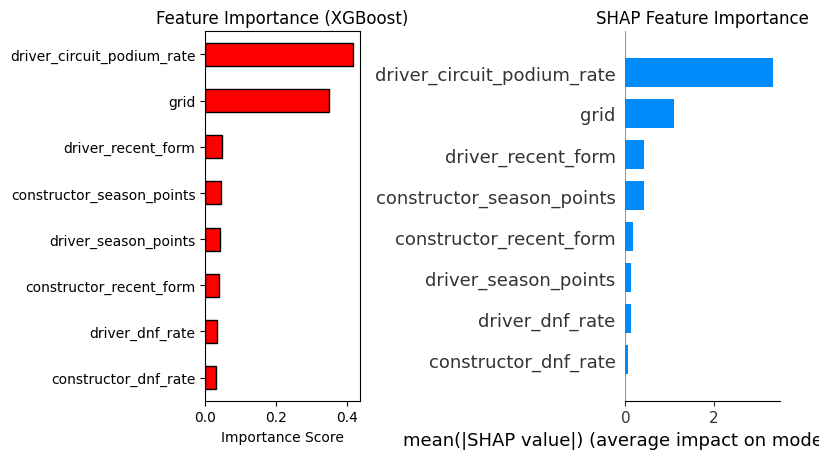

✅ Model saved to backend/model.pkl
✅ Features saved to backend/features.pkl


In [19]:
import shap
import joblib

# ── Feature Importance ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost built-in importance
feat_importance = pd.Series(model.feature_importances_, index=FEATURES)
feat_importance.sort_values().plot(kind='barh', ax=axes[0], color='red', edgecolor='black')
axes[0].set_title('Feature Importance (XGBoost)')
axes[0].set_xlabel('Importance Score')

# SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
axes[1].set_title('SHAP Feature Importance')

plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save the model ──
joblib.dump(model, '../backend/model.pkl')
joblib.dump(FEATURES, '../backend/features.pkl')
print("✅ Model saved to backend/model.pkl")
print("✅ Features saved to backend/features.pkl")

In [20]:
# Test on a real 2023 race - let's predict the Australian GP
aus_2023 = test[(test['year'] == 2023) & (test['round'] == 1)].copy()
aus_2023['predicted_prob'] = model.predict_proba(aus_2023[FEATURES])[:, 1]

print("🏎️  2023 Australian GP - Model Predictions vs Reality")
print("="*55)
result = aus_2023[['driver_name', 'predicted_prob', 'positionOrder', 'podium']]
result = result.sort_values('predicted_prob', ascending=False).head(10)
result.columns = ['Driver', 'Podium Probability', 'Actual Finish', 'Actually Podiumed']
print(result.to_string(index=False))

🏎️  2023 Australian GP - Model Predictions vs Reality
         Driver  Podium Probability  Actual Finish  Actually Podiumed
 Max Verstappen            0.965701              1                  1
   Sergio Pérez            0.950100              2                  1
 Lewis Hamilton            0.924439              5                  0
Charles Leclerc            0.825890             19                  0
   Carlos Sainz            0.799387              4                  0
Fernando Alonso            0.197890              3                  1
   Lance Stroll            0.131878              6                  0
   Esteban Ocon            0.106281             18                  0
Alexander Albon            0.018850             10                  0
Valtteri Bottas            0.013544              8                  0


In [21]:
# Save the cleaned dataset for the backend to use
df.to_csv('../data/f1_master.csv', index=False)
print(f"✅ Master dataset saved: {len(df)} rows")

# Quick model summary to screenshot for your README
print("\n" + "="*50)
print("       F1 PODIUM PREDICTOR - MODEL SUMMARY")
print("="*50)
print(f"  Training data:  2010 - 2022 ({X_train.shape[0]} race entries)")
print(f"  Test data:      2023 - 2024 ({X_test.shape[0]} race entries)")
print(f"  Model:          XGBoost Classifier")
print(f"  Features:       {len(FEATURES)}")
print(f"  ROC-AUC:        0.956")
print(f"  Podium Recall:  93%")
print(f"  Podium Precision: 57%")
print(f"\n  Top features:")
for feat, imp in feat_importance.sort_values(ascending=False).items():
    print(f"    {feat:<35} {imp:.3f}")
print("="*50)

✅ Master dataset saved: 6436 rows

       F1 PODIUM PREDICTOR - MODEL SUMMARY
  Training data:  2010 - 2022 (5517 race entries)
  Test data:      2023 - 2024 (919 race entries)
  Model:          XGBoost Classifier
  Features:       8
  ROC-AUC:        0.956
  Podium Recall:  93%
  Podium Precision: 57%

  Top features:
    driver_circuit_podium_rate          0.415
    grid                                0.349
    driver_recent_form                  0.047
    constructor_season_points           0.046
    driver_season_points                0.041
    constructor_recent_form             0.038
    driver_dnf_rate                     0.033
    constructor_dnf_rate                0.031
